# EXERCISE

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

from Bio.SeqUtils import MeltingTemp as mt
from Bio.SeqUtils import molecular_weight as mw
from Bio.SeqUtils import gc_fraction
from Bio.SeqUtils import nt_search
from Bio.pairwise2 import format_alignment, align
from Bio import pairwise2
from Bio import SeqIO
from Levenshtein import distance

c:\Anaconda3\envs\computational_biology\Lib\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


# 1. Sequence Manipulation 

In [ ]:
# Find and display the total length of Sequence A and B.
seqA = SeqIO.read('a.fasta', 'fasta').seq
seqB = SeqIO.read('b.fasta', 'fasta').seq

print(f"{len(seqA) + len(seqB)} --> {len(seqA)} + {len(seqB)}")

2933 --> 1883 + 1050


In [8]:
# Find and display which index the first time codon (TAC) appears in both Sequence A and B. 
firstA = nt_search(str(seqA), 'TAC')[1]
firstB = nt_search(str(seqB), 'TAC')[1]
print(firstA)
print(firstB)

507
85


In [16]:
# Take the first 10 nucleotides from Sequence A, and the last 15 nucleotides from Sequence B. Then combine the sequences and reverse it to a new sequence, Sequence C. 
sequenceA = seqA[:10:] # first 10
sequenceB = seqB[-15::] # last 15
sequenceC = sequenceA + sequenceB # Combine
sequenceC[::-1] # Reverse

Seq('CAGCTGAAAGCGGACGGTTGTGGTA')

# 2. Sequence Analysis & Plotting

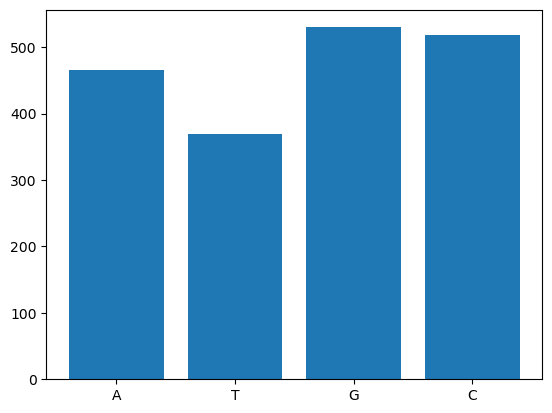

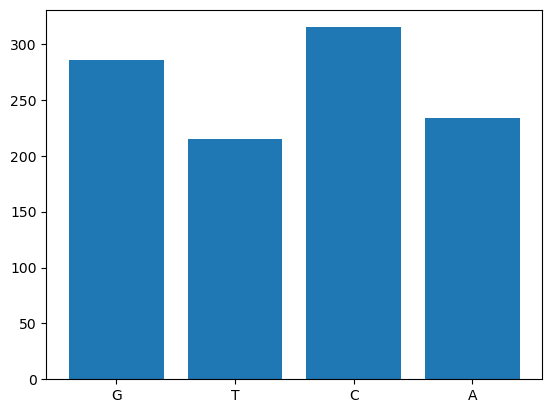

In [ ]:
# Determine and display the nucleotides base (A, C, G, T) frequency for Sequence A, B, and C with a chart using matplotlib library. 
counter_a = Counter(seqA)
counter_b = Counter(seqB)
plt.bar(counter_a.keys(), counter_a.values())
plt.show()
plt.bar(counter_b.keys(), counter_b.values())
plt.show()

In [22]:
# Determine and display the GC & AT content percentage for Sequence A, B, and C.
gc_a = gc_fraction(seqA) * 100
print(f"gc: {gc_a:.2f}%")
print(f"at: {100 - gc_a:.2f}%")

gc: 55.71%
at: 44.29%


In [24]:
# Determine and display the melting temperature for Sequence A, B, and C (using built-inWallace Method).
mt_a = mt.Tm_Wallace(seqA)
mt_a 

5864.0

In [25]:
# Determine and display the molecular weight for Sequence A, B, and C.
mw_a = mw(seqA)
mw_a

582470.8097999999

# 3. DNA & mRNA Protein Synthesis

In [ ]:
# Transcribe and display the DNA Sequence A, B, and C into mRNA Sequences. 
mRNA_a = seqA.transcribe() 
mRNA_a

Seq('AUGGUGUUGGAUCUGGACUUGUUUCGGACGGAUAAAGGAGGAGACCCGGACCGC...UCA')

In [27]:
# Translate and display the mRNA Sequence A, B, and C into amino acids sequences. (Clue: for translate, use the mRNA sequences that already transcribed on the first step) 
aminoAcid_a = mRNA_a.translate()
aminoAcid_a

c:\Anaconda3\envs\computational_biology\Lib\site-packages\Bio\Seq.py:2879: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


Seq('MVLDLDLFRTDKGGDPDRIRETQKNRFKDPGLVDRLVKADGEWRKCRFQTDNLN...VAS')

# 4. Sequence Alignment & Similarities

In [ ]:
# Perform local alignment pairwise between Sequence A and Sequence “CGCTACTAGCATGCGCAT” and display the alignments’ score. (Clue: Use localxx) 
local_alignment_a = align.localxx(seqA, "CGCTACTAGCATGCGCAT")
for a in local_alignment_a:
    print(format_alignment(*a))

1815 CAGCTCTCCCTGGAACCACACTCACTTGTGCTTTTCCTCCTAAATAAAGCTGTTCCATGTAGCAAGT
     | |      ||        ||| |     |         |       |  ||   |     || | |
   1 C-G------CT--------ACT-A-----G---------C-------A--TG---C-----GC-A-T
  Score=18

1813 CACAGCTCTCCCTGGAACCACACTCACTTGTGCTTTTCCTCCTAAATAAAGCTGTTCCATGTAGCAAGT
     |   |      ||        ||| |     |         |       |  ||   |     || | |
   1 C---G------CT--------ACT-A-----G---------C-------A--TG---C-----GC-A-T
  Score=18

1811 CTCACAGCTCTCCCTGGAACCACACTCACTTGTGCTTTTCCTCCTAAATAAAGCTGTTCCATGTAGCAAGT
     |     |      ||        ||| |     |         |       |  ||   |     || | |
   1 C-----G------CT--------ACT-A-----G---------C-------A--TG---C-----GC-A-T
  Score=18

1807 CTGGCTCACAGCTCTCCCTGGAACCACACTCACTTGTGCTTTTCCTCCTAAATAAAGCTGTTCCATGTAGCAAGT
     |         |      ||        ||| |     |         |       |  ||   |     || | |
   1 C---------G------CT--------ACT-A-----G---------C-------A--TG---C-----GC-A-T
  Score=18

1806 CCTGGCTCACAGCTCTCCCTGGAACCACA

In [29]:
# Perform global alignment pairwise between Sequence B and Sequence “CAGTGCGCTAGCAGCTACGTGTG” and display the alignments’ score. (Clue: Use globalxx) 
global_alignment_b = align.globalxx(seqA, "CAGTGCGCTAGCAGCTACGTGTG")
for b in global_alignment_b:
    print(format_alignment(*b))

ATGGTGTTGGATCTGGACTTGTTTCGGACGGATAAAGGAGGAGACCCGGACCGCATCCGAGAGACGCAAAAGAACCGCTTCAAGGACCCGGGACTCGTGGATCGGCTGGTGAAGGCGGACGGCGAGTGGCGAAAATGCAGATTTCAGACCGACAACTTGAACAAGCTGAAGAACCTATGCAGCAAGACAATTGGAGAGAAAATGAAGAAAAAAGAGCCAGTGGGAAATGATGAGTCCATTCCGGAGAACTTGTTAAATCTCGATGACCTCACTTCAGACACTTTAGCTAACCTGAAAGTGTCACAGATCAAAAAACTCCGACTCCTCATCGACGAAGCCATCCTGAAGTGTGACGCCCAGCGGATAAAGCTGCAGGAATAGCGGTTTGAGAACCTCCGCGAGCGATTCGATGGCTAGGTCCTGCATCCCTCGGTGCCCATCAGTAACGATGAGGATGCGGACAACAAAGTCGAGAGGATCTGGGGTGACTGCACCGTCAAGAAGAAGTACTCGCACGTGGACCTGGTGGTGATGGTCGATGGCTTTGAAGGCGAAAAAGGGGTCGTGGTGGCTGGCAGTCGAGGGTACTTCCTGAAGGGGCCCCTGGTGTTCCTGGAACAGGCGCTCATCCAGTACGCCCTTCGCACCTTGGGAAGTCGGGGCTACATTCCCATTTACACCCCGTTTTTCATGAGGAAGGAGGTCATGCAGGAGGTGGCACAGCTCAGCCAGTTTGATGAAGAGCTTTACAAGGTGATTGGCAAAGGCAGTGAAAAGTCTGACGACAACTCCTACGATGAGAAATACCTGATTGCCACCTCCGAGCAGCCCATCGCTGCTCTCCACCGAGATGAGTGGCTACGGCCAGAGGATTTGCCCATCAAGTATGCTGGCCTGTCCACCTGCTTTCGCCAGGAGGTGGGCTCCCACGGCCGGGACACCCGCGGCATCTTCCGAGTCCATCAGTTTGAGAAGATCGAGCAGTTTGTCTACGCGTCAC

In [30]:
# Find and display the Levenshtein distance between Sequence A and B 
distance(seqA, seqB)

1039